# Wine Dataset - Exploratory Data Analysis and Preprocessing

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler

## 1. Dataset Description & Understanding the Data Matrix

**Dataset Chosen** : Wine (UCI) - created by Stefan Aeberhard and M. Forina

**Description** :
The [Wine dataset](https://archive.ics.uci.edu/dataset/109/wine) contains chemical analysis of 178 wine samples from three cultivars in the same region of Italy. Each observation includes 13 continuous chemical measurements such as alcohol content, flavanoids, ash, etc. The class label indicates the wine cultivar.

### 1.1 Load Data & Display Dimensions.

In [4]:
columns = ["class","alcohol","malic_acid","ash","alcalinity_of_ash","magnesium","total_phenols","flavanoids","nonflavanoid_phenols","proanthocyanins","color_intensity","hue","od280_od315","proline"]

In [6]:
df = pd.read_csv("wine.data", header = None, names = columns)

In [7]:
print(f"Dataset shape: {df.shape[0]} observations × {df.shape[1]} variables")
print(f"Number of observations (rows): {df.shape[0]}")
print(f"Number of variables (columns): {df.shape[1]} (1 class label + 13 features)")
print(f"\nClass distribution:\n{df['class'].value_counts().sort_index()}")
print("\nFirst 5 rows:")
df.head()

Dataset shape: 178 observations × 14 variables
Number of observations (rows): 178
Number of variables (columns): 14 (1 class label + 13 features)

Class distribution:
class
1    59
2    71
3    48
Name: count, dtype: int64

First 5 rows:


,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


---
## 2. Exploratory Data Analysis (EDA)
### 2.1 Descriptive Statistics

In [11]:
quantitative_df = df.drop(columns = "class")

In [12]:
descriptive_stats = pd.DataFrame({
    "Min": quantitative_df.min(),
    "Max": quantitative_df.max(),
    "Range": quantitative_df.max() - quantitative_df.min(),
    "Mean": quantitative_df.mean(),
    "Median": quantitative_df.median(),
    "Variance": quantitative_df.var(),
    "Standard Deviation": quantitative_df.std()
})

descriptive_stats.round(3)

,Min,Max,Range,Mean,Median,Variance,Standard Deviation
alcohol,11.03,14.83,3.80,13.001,13.050,0.659,0.812
malic_acid,0.74,5.80,5.06,2.336,1.865,1.248,1.117
ash,1.36,3.23,1.87,2.367,2.360,0.075,0.274
alcalinity_of_ash,10.60,30.00,19.40,19.495,19.500,11.153,3.340
magnesium,70.00,162.00,92.00,99.742,98.000,203.989,14.282
total_phenols,0.98,3.88,2.90,2.295,2.355,0.392,0.626
flavanoids,0.34,5.08,4.74,2.029,2.135,0.998,0.999
nonflavanoid_phenols,0.13,0.66,0.53,0.362,0.340,0.015,0.124
proanthocyanins,0.41,3.58,3.17,1.591,1.555,0.328,0.572
color_intensity,1.28,13.00,11.72,5.058,4.690,5.374,2.318


--------------------------------------------------------------------------------------------------------------------------------------------------------

**Table 1 : Descriptive Statistics and Variable Characteristics of the Wine Dataset**

| Variable | Type | Nature | Description | Minimum | Maximum | Range | Mean | Median | Variance | Standard Deviation |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Class | Qualitative | Nominal | Wine cultivar (1, 2 or 3) |  |  |  |  |  |  |  |
| Alcohol | Quantitative | Continuous | Alcohol content of the wine | 11.03 | 14.83 | 3.80 | 13.001 | 13.050 | 0.659 | 0.812 |
| Malic Acid | Quantitative | Continuous | Malic acid concentration | 0.74 | 5.80 | 5.06 | 2.336 | 1.865 | 1.248 | 1.117 |
| Ash | Quantitative | Continuous | Ash content of the wine | 1.36 | 3.23 | 1.87 | 2.367 | 2.360 | 0.075 | 0.274 |
| Alcalinity of Ash | Quantitative | Continuous | Alkalinity of ash | 10.60 | 30.00 | 19.40 | 19.495 | 19.500 | 11.153 | 3.340 |  
| Magnesium | Quantitative | Discrete | Magnesium content | 70.00 | 162.00 | 92.00 | 99.742 | 98.000 | 203.989 | 14.282 |  
| Total Phenols | Quantitative | Continuous | Total phenolic compounds | 0.98 | 3.88 | 2.90 | 2.295 | 2.355 | 0.392 | 0.626 |
| Flavanoids | Quantitative | Continuous | Flavanoid content | 0.34 | 5.08 | 4.74 | 2.029 | 2.135 | 0.998 | 0.999 |
| Non-flavanoid Phenols | Quantitative | Continuous | Non-flavanoid phenolic compounds | 0.13 | 0.66 | 0.53 | 0.362 | 0.340 | 0.015 | 0.124 |
| Proanthocyanins | Quantitative | Continuous | Proanthocyanin concentration | 0.41 | 3.58 | 3.17 | 1.591 | 1.555 | 0.328 | 0.572 |
| Color Intensity | Quantitative | Continuous | Intensity of wine color | 1.28 | 13.00 | 11.72 | 5.058 | 4.690 | 5.374 | 2.318 |
| Hue | Quantitative | Continuous | Hue of the wine | 0.48 | 1.71 | 1.23 | 0.957 | 0.965 | 0.052 | 0.229 |
| OD280/OD315 | Quantitative | Continuous | Ratio of optical densities at 280nm and 315nm | 1.27 | 4.00 | 2.73 | 2.612 | 2.780 | 0.504 | 0.710 |
| Proline | Quantitative | Discrete | Proline amino acid content | 278.00 | 1680.00 | 1402.00 | 746.893 | 673.500 | 99166.717 | 314.907 |

 **Highlights:**
 - **Scale differences are huge:** The variables are measured on very different scales; for example, proline has a much larger range than non-flavanoid phenols. This strongly motivates standardization before applying PCA.
 - **Proline** and **magnesium** exhibit the largest variances, indicating the greatest raw spread due to measurement scale rather than intrinsic importance.
 - For most variables, the mean and median are relatively close, suggesting limited skewness in their distributions.
 - **Malic acid** and **color intensity** show noticeable mean–median differences, indicating possible right-skewness or the influence of high-value observations.

--------------------------------------------------------------------------------------------------------------------------------------------------------

### 2.2 Histograms

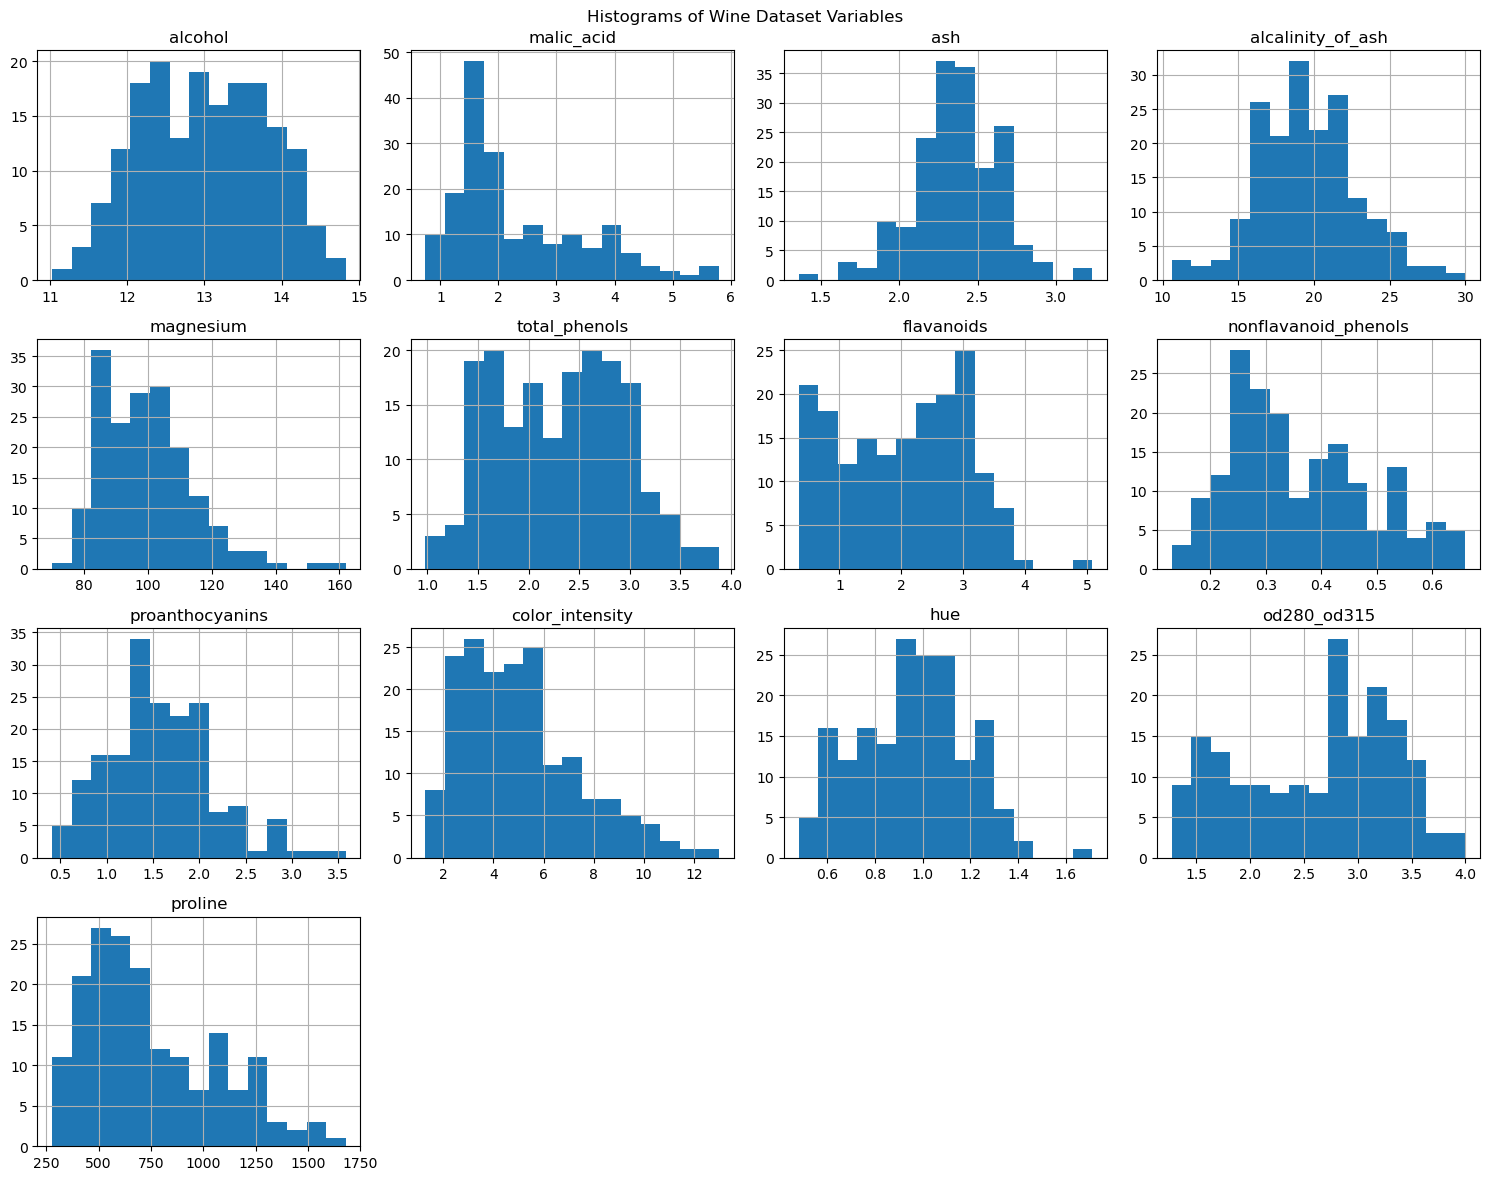

In [8]:
quantitative_df.hist(bins=15, figsize=(15, 12))
plt.suptitle("Histograms of Wine Dataset Variables")
plt.tight_layout()
plt.show()

**Interpretation:** Most variables appear unimodal with moderate spread, though several deviate from perfect symmetry. **Malic acid** and **color intensity** exhibit mild right-skew, indicating the presence of higher-value observations. **Proline** shows noticeable right-skew with a long tail toward larger values.

### 2.3 Boxplots

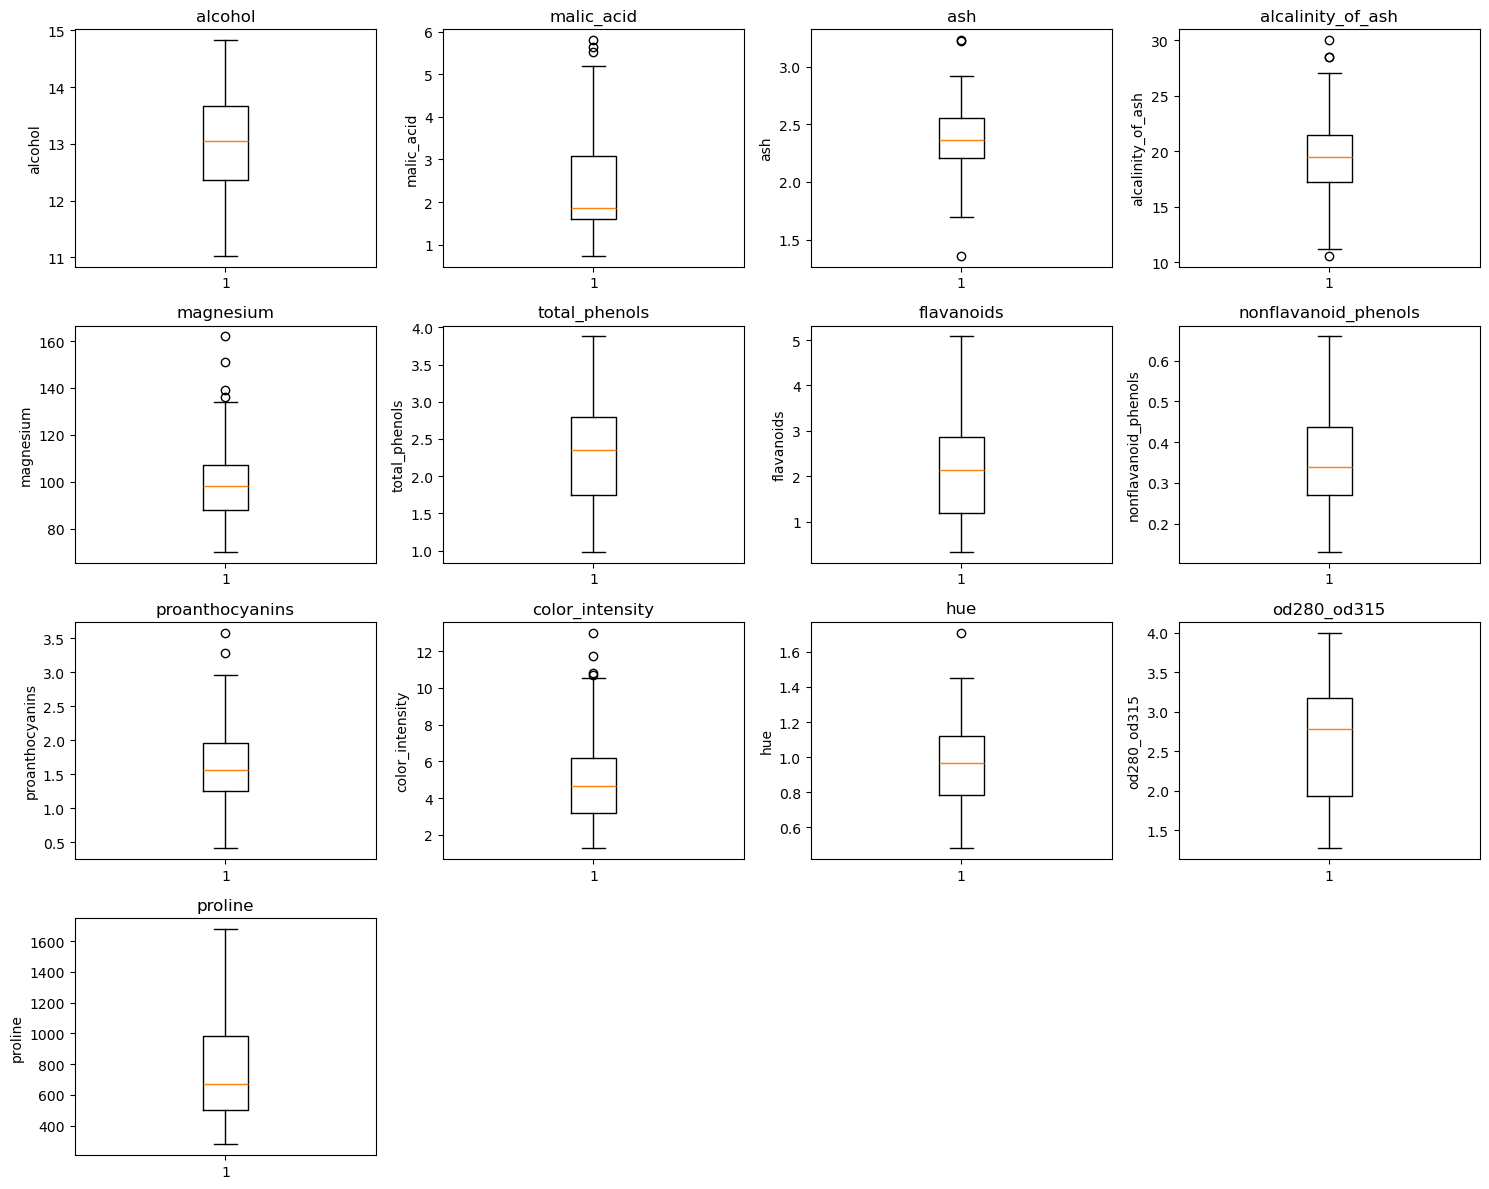

In [38]:
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()
cols = ["alcohol","malic_acid","ash","alcalinity_of_ash","magnesium","total_phenols","flavanoids","nonflavanoid_phenols","proanthocyanins","color_intensity","hue","od280_od315","proline"]


for ax, col in zip(axes, cols):
    ax.boxplot(df[col])
    ax.set_title(col)
    ax.set_ylabel(col)

# Remove empty subplot
fig.delaxes(axes[-1])
fig.delaxes(axes[-2])
fig.delaxes(axes[-3])

plt.tight_layout()
plt.show()

**Interpretation:** Several variables show observations beyond the whiskers in the boxplots, indicating the presence of potential outliers. **Malic acid**, **magnesium**, and **proline** exhibit particularly prominent high-value outliers, with additional outliers visible in variables such as **color intensity** and **alcalinity of ash**.

### 2.4 Scatterplot Matrix (coloured by class)

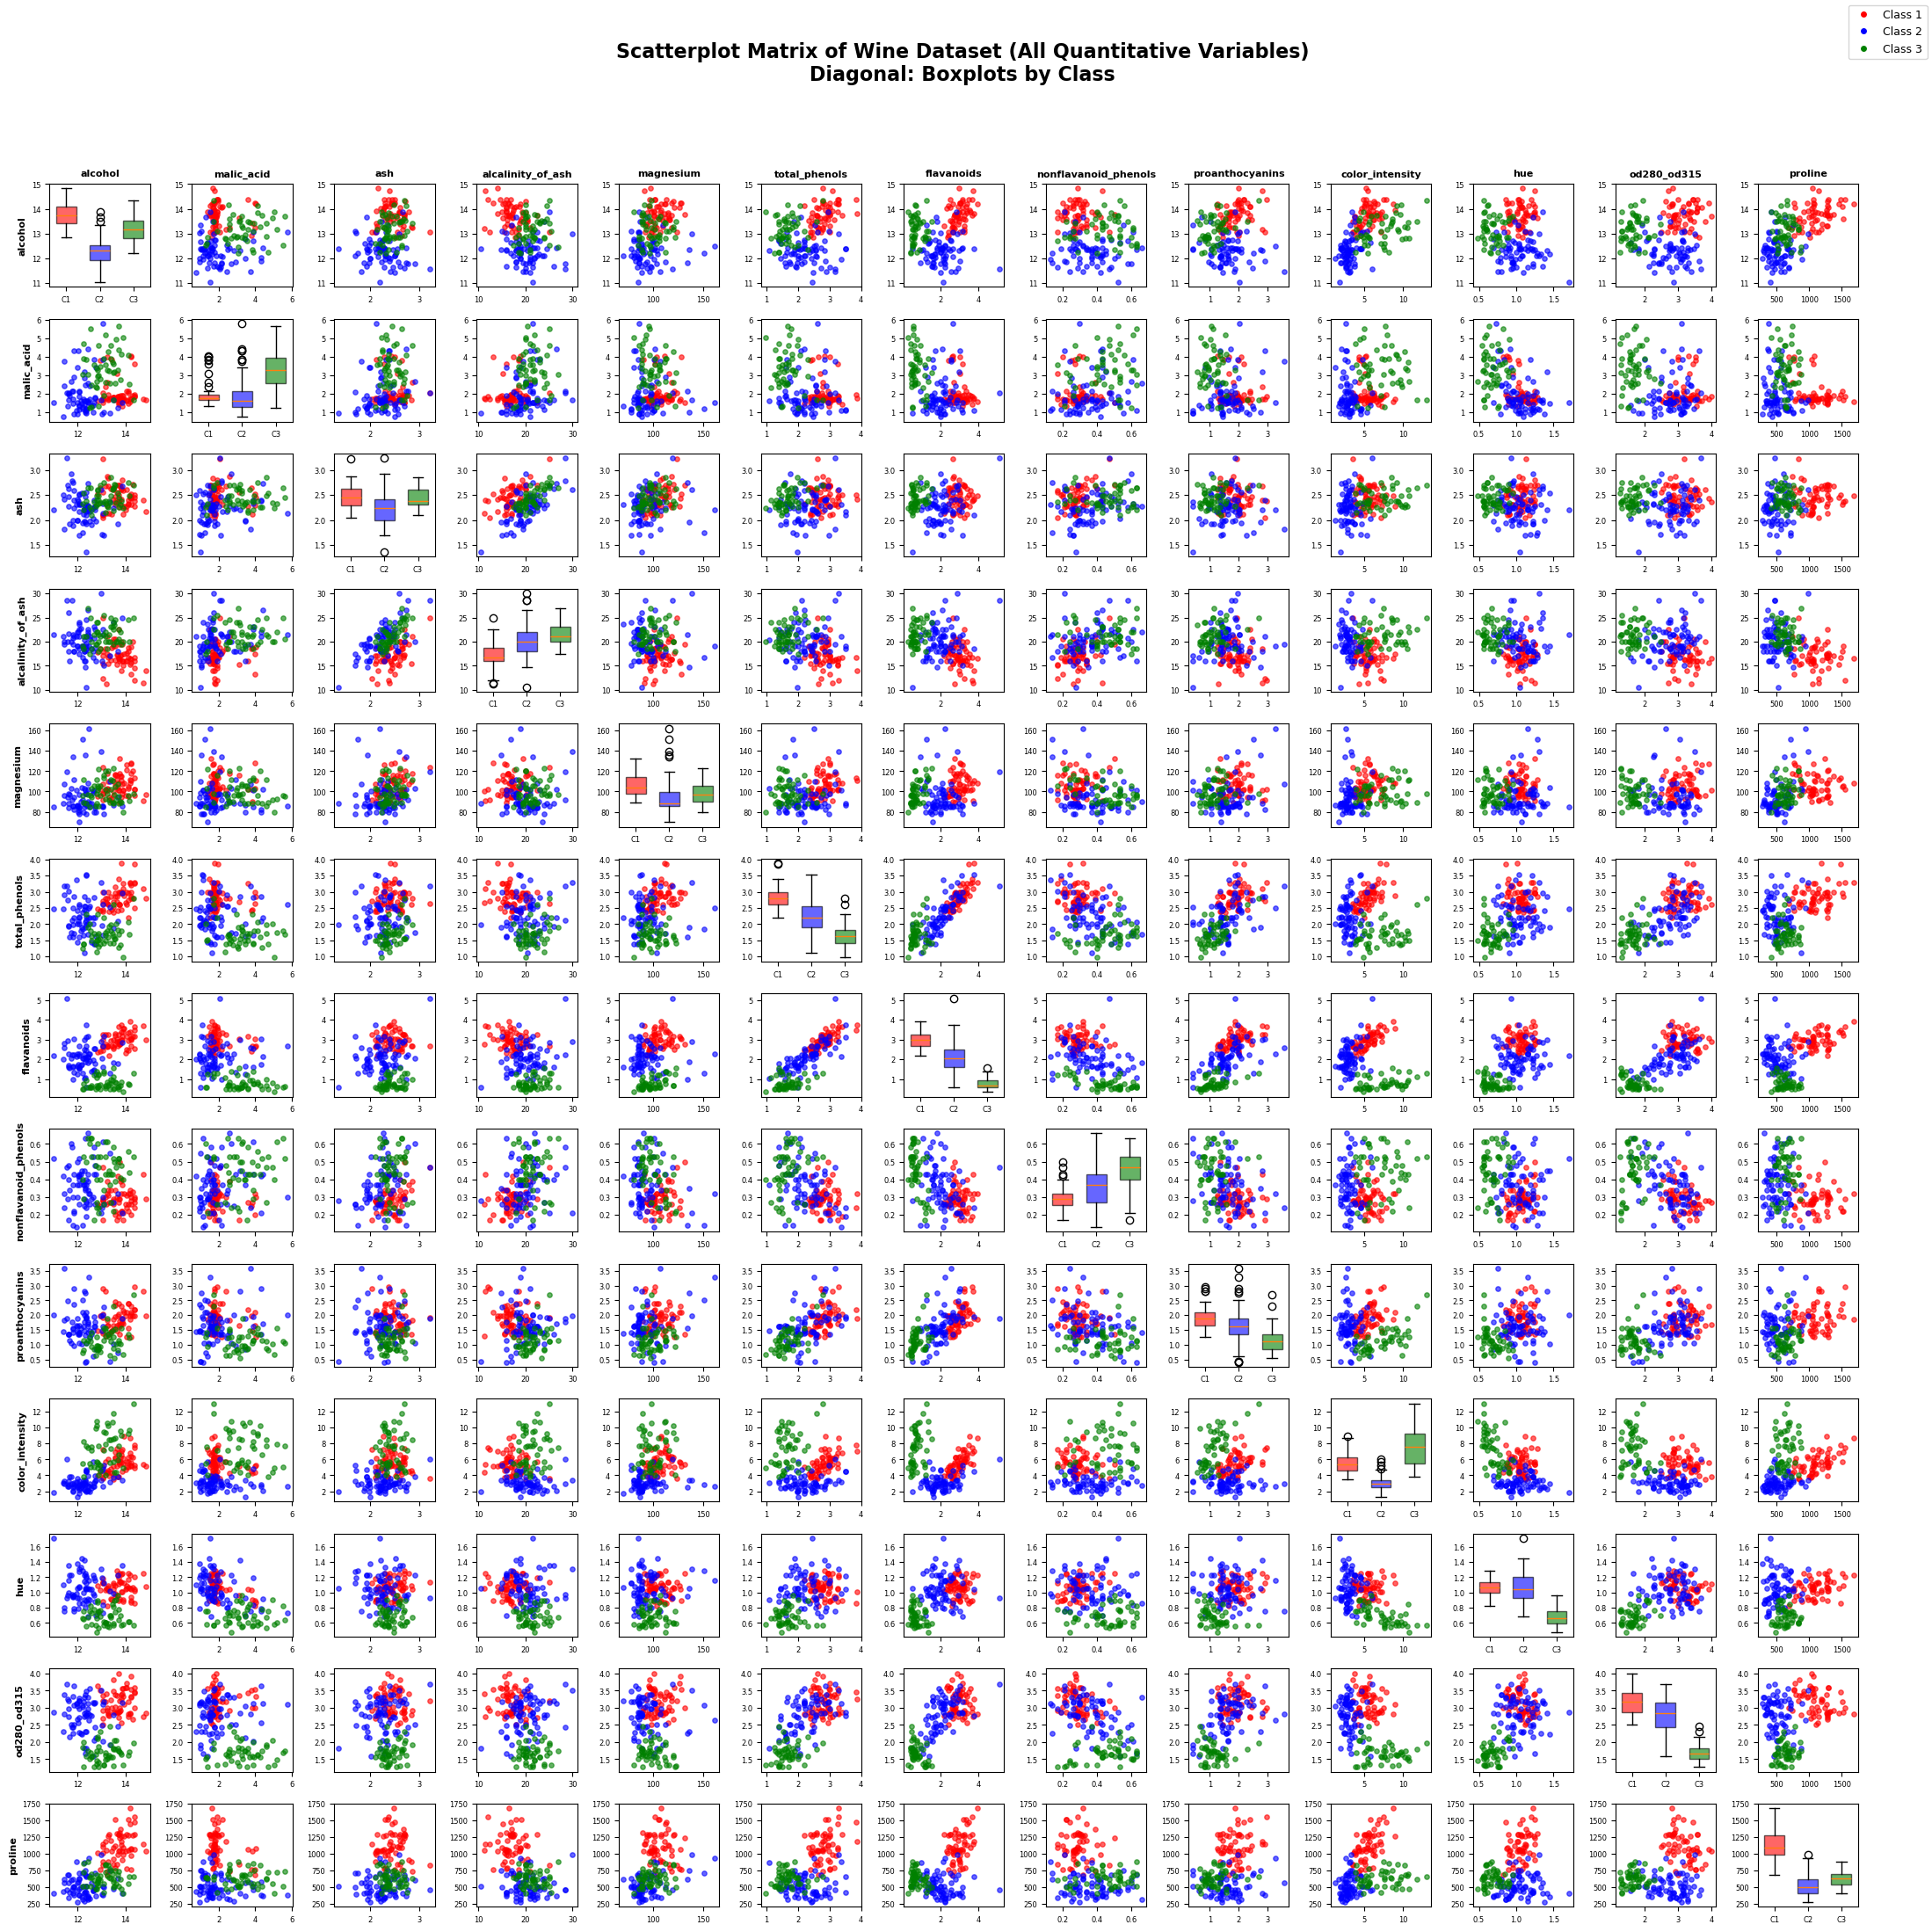

In [10]:
cols = ["alcohol","malic_acid","ash","alcalinity_of_ash","magnesium","total_phenols","flavanoids","nonflavanoid_phenols","proanthocyanins","color_intensity","hue","od280_od315","proline"]

n = len(cols)
fig = plt.figure(figsize=(22, 22))
colors_map = {1: 'red', 2: 'blue', 3: 'green'}

for i in range(n):
    for j in range(n):
        ax = fig.add_subplot(n, n, i*n + j + 1)
        if i == j:
            data = [df.loc[df['class'] == cls, cols[i]]
                for cls in sorted(df['class'].unique())
            ]
            bp = ax.boxplot(data,patch_artist=True,widths=0.6,showfliers=True)

            for patch, cls in zip(bp['boxes'], sorted(df['class'].unique())):
                patch.set_facecolor(colors_map[cls])
                patch.set_alpha(0.6)

            ax.set_xticks(range(1, len(colors_map) + 1))
            ax.set_xticklabels([f"C{cls}" for cls in sorted(df['class'].unique())],fontsize=6)
        else:
            for cls in sorted(df['class'].unique()):
                mask = df['class'] == cls
                ax.scatter(df.loc[mask, cols[j]],df.loc[mask, cols[i]],c=colors_map[cls],alpha=0.6,s=15)
        if i == 0:
            ax.set_title(cols[j], fontsize=8, fontweight='bold')
        if j == 0:
            ax.set_ylabel(cols[i], fontsize=8, fontweight='bold')
        ax.tick_params(labelsize=6)

handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=colors_map[cls], markersize=6,
               label=f'Class {cls}')
    for cls in sorted(df['class'].unique())
]

fig.legend(handles=handles, loc='upper right', fontsize=9)
fig.suptitle("Scatterplot Matrix of Wine Dataset (All Quantitative Variables)\nDiagonal: Boxplots by Class",fontsize=16,fontweight='bold')
plt.tight_layout(rect=[0, 0, 0.97, 0.95])
plt.show()

**Interpretation**: The three wine cultivars form visibly distinct groupings in several feature pairs, indicating structured multivariate variation and partial class separation. These patterns suggest the presence of correlated variables and dominant variance directions, which PCA can effectively summarize into a smaller number of uncorrelated components.

### 2.5 Correlation Matrix

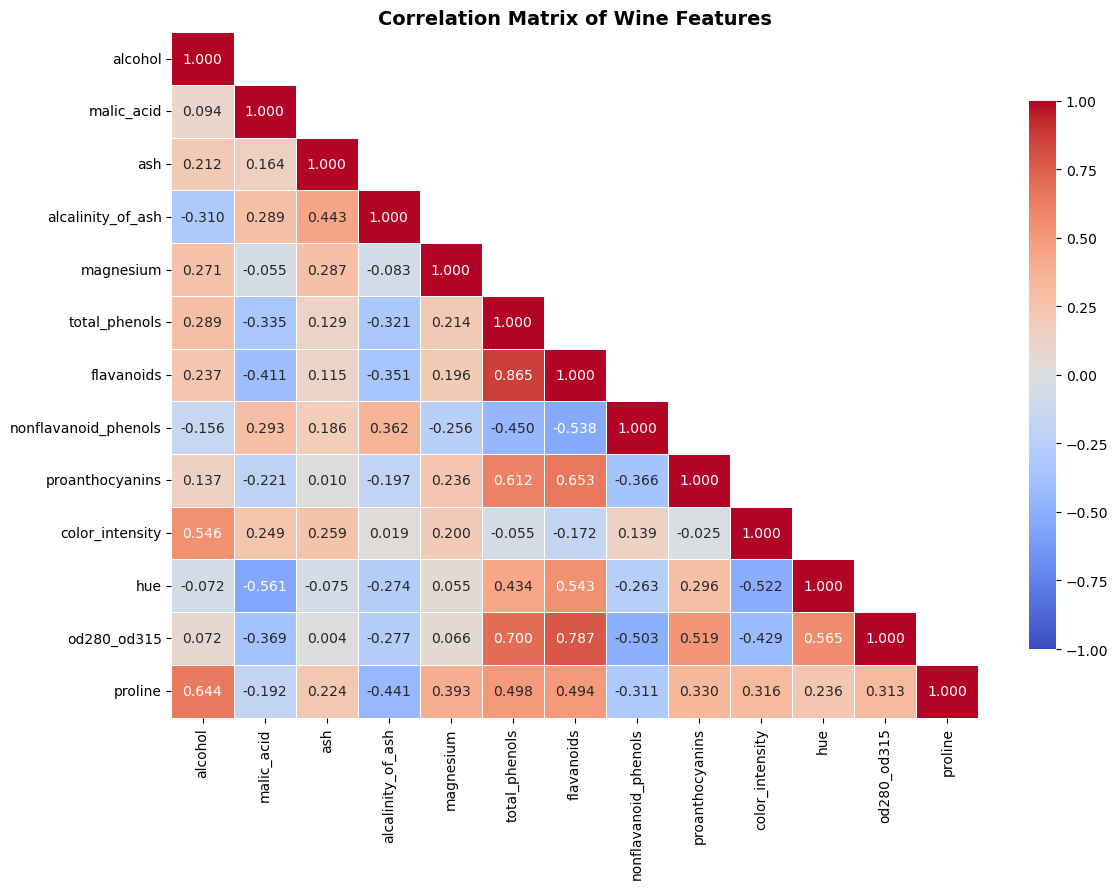

In [17]:
corr_matrix = quantitative_df.corr()
fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Wine Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation**: Strong positive correlations are observed among **Flavanoids**, **Total Phenols**, and **OD280/OD315**, indicating that these phenolic-related variables vary together. Several moderate negative correlations are also present, such as between **Malic Acid** and **Hue** and between **Nonflavanoid Phenols** and **Flavanoids**. Some variables, including Magnesium, exhibit weak correlations with many others.

---
## 3. Data Preprocessing
### 3.1 Missing Values

In [19]:
miss     = df.isnull().sum()
miss_pct = (miss / len(df) * 100)
miss_df  = pd.DataFrame({'Missing Count': miss, 'Missing %': miss_pct})
print(f"Total missing values in the dataset: {df.isnull().sum().sum()}\n")
miss_df

Total missing values in the dataset: 0



,Missing Count,Missing %
class,0,0.0
alcohol,0,0.0
malic_acid,0,0.0
ash,0,0.0
alcalinity_of_ash,0,0.0
magnesium,0,0.0
total_phenols,0,0.0
flavanoids,0,0.0
nonflavanoid_phenols,0,0.0
proanthocyanins,0,0.0


The dataset does not contain missing values; therefore, no deletion or imputation is required.

### 3.2 Outlier Detection (Z-Score Method)

In [22]:
z_scores = np.abs(zscore(quantitative_df))
outlier_counts = (z_scores > 3).sum(axis=0)
outlier_df = pd.DataFrame({'Feature': cols,
                           'Outliers (|z| > 3)': outlier_counts})
total_outliers = (z_scores > 3).any(axis=1).sum()
print(f"Observations with |z| > 3 in at least one feature: {total_outliers} / {len(quantitative_df)}\n")
print(outlier_df.to_string(index=False))

Observations with |z| > 3 in at least one feature: 10 / 178

             Feature  Outliers (|z| > 3)
             alcohol                   0
          malic_acid                   1
                 ash                   3
   alcalinity_of_ash                   1
           magnesium                   2
       total_phenols                   0
          flavanoids                   1
nonflavanoid_phenols                   0
     proanthocyanins                   1
     color_intensity                   1
                 hue                   1
         od280_od315                   0
             proline                   0


**Interpretation**: A small number of observations are flagged as potential outliers based on the |z| > 3 criterion, affecting 10 out of 178 samples. These extreme values are limited in number and distributed across several variables, with no indication of systematic measurement error. Given that the data represent real chemical measurements and the outliers fall within plausible ranges, they are retained for analysis.

### 3.3 Standardisation

In [27]:
scaler = StandardScaler()

standardized_data = scaler.fit_transform(quantitative_df)

standardized_df = pd.DataFrame(
    standardized_data,
    columns=quantitative_df.columns
)

before_summary = quantitative_df.describe()

after_summary = standardized_df.describe()

print("Summary BEFORE standardization:\n")
before_summary.round(3)

Summary BEFORE standardization:



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


In [28]:
print("\nSummary AFTER standardization:\n")
after_summary.round(3)


Summary AFTER standardization:



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003
min,-2.434,-1.433,-3.679,-2.671,-2.088,-2.107,-1.696,-1.868,-2.069,-1.634,-2.095,-1.895,-1.493
25%,-0.788,-0.659,-0.572,-0.689,-0.824,-0.885,-0.828,-0.740,-0.597,-0.795,-0.768,-0.952,-0.785
50%,0.061,-0.423,-0.024,0.002,-0.122,0.096,0.106,-0.176,-0.063,-0.159,0.033,0.238,-0.234
75%,0.836,0.670,0.698,0.602,0.510,0.809,0.849,0.610,0.629,0.494,0.713,0.789,0.758
max,2.260,3.109,3.156,3.155,4.371,2.540,3.063,2.402,3.485,3.435,3.302,1.961,2.971


**Why standardise?**
In multivariate analysis, variables are often measured on very different scales. For example, proline values range in the hundreds, while nonflavanoid phenols take values less than one. In variance-based methods such as PCA, variables with larger numerical spread would dominate the analysis simply because they contribute more variance, not because they are more informative. Standardization, which centers variables to zero mean and scales them to unit variance, removes the effect of measurement units and ensures that PCA captures the underlying multivariate structure rather than differences in scale.

**Compare summaries before and after standardization.**
Before standardization, the summary statistics are strongly influenced by the original measurement scales, causing large-scale variables to dominate variance. After standardization, all variables are centered and scaled to unit variance, removing scale effects and allowing meaningful comparison across variables. This ensures that multivariate techniques such as PCA capture genuine data structure rather than artifacts of differing units.

---
## 4. Preparation for PCA
### 4.1 Covariance Matrix of Standardised Data
**Before Standardization** :

In [23]:
cov_matrix_bfr_std = quantitative_df.cov()
cov_matrix_bfr_std

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
alcohol,0.659062,0.085611,0.047115,-0.841093,3.139878,0.146887,0.192033,-0.015754,0.063518,1.028283,-0.013313,0.041698,164.567185
malic_acid,0.085611,1.248015,0.050277,1.076332,-0.870780,-0.234338,-0.458630,0.040733,-0.141147,0.644838,-0.143326,-0.292447,-67.548867
ash,0.047115,0.050277,0.075265,0.406208,1.122937,0.022146,0.031535,0.006358,0.001516,0.164654,-0.004682,0.000762,19.319739
alcalinity_of_ash,-0.841093,1.076332,0.406208,11.152686,-3.974760,-0.671149,-1.172083,0.150422,-0.377176,0.145024,-0.209118,-0.656234,-463.355345
magnesium,3.139878,-0.870780,1.122937,-3.974760,203.989335,1.916470,2.793087,-0.455563,1.932832,6.620521,0.180851,0.669308,1769.158700
total_phenols,0.146887,-0.234338,0.022146,-0.671149,1.916470,0.391690,0.540470,-0.035045,0.219373,-0.079998,0.062039,0.311021,98.171057
flavanoids,0.192033,-0.458630,0.031535,-1.172083,2.793087,0.540470,0.997719,-0.066867,0.373148,-0.399169,0.124082,0.558262,155.447492
nonflavanoid_phenols,-0.015754,0.040733,0.006358,0.150422,-0.455563,-0.035045,-0.066867,0.015489,-0.026060,0.040121,-0.007471,-0.044469,-12.203586
proanthocyanins,0.063518,-0.141147,0.001516,-0.377176,1.932832,0.219373,0.373148,-0.026060,0.327595,-0.033504,0.038665,0.210933,59.554334
color_intensity,1.028283,0.644838,0.164654,0.145024,6.620521,-0.079998,-0.399169,0.040121,-0.033504,5.374449,-0.276506,-0.705813,230.767480


**After Standardization** :

In [29]:
cov_matrix_aft_std = standardized_df.cov()
cov_matrix_aft_std

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
alcohol,1.005650,0.094930,0.212740,-0.311988,0.272328,0.290734,0.238153,-0.156810,0.137470,0.549451,-0.072153,0.072752,0.647357
malic_acid,0.094930,1.005650,0.164972,0.290130,-0.054883,-0.337061,-0.413329,0.294632,-0.221993,0.250392,-0.564467,-0.370794,-0.193095
ash,0.212740,0.164972,1.005650,0.445872,0.288206,0.129708,0.115727,0.187283,0.009706,0.260350,-0.075089,0.003933,0.224890
alcalinity_of_ash,-0.311988,0.290130,0.445872,1.005650,-0.083804,-0.322928,-0.353355,0.363966,-0.198442,0.018838,-0.275503,-0.278332,-0.443086
magnesium,0.272328,-0.054883,0.288206,-0.083804,1.005650,0.215613,0.196890,-0.257742,0.237776,0.201080,0.055711,0.066377,0.395573
total_phenols,0.290734,-0.337061,0.129708,-0.322928,0.215613,1.005650,0.869448,-0.452477,0.615873,-0.055448,0.436132,0.703904,0.500929
flavanoids,0.238153,-0.413329,0.115727,-0.353355,0.196890,0.869448,1.005650,-0.540939,0.656379,-0.173353,0.546549,0.791641,0.496985
nonflavanoid_phenols,-0.156810,0.294632,0.187283,0.363966,-0.257742,-0.452477,-0.540939,1.005650,-0.367912,0.139843,-0.264123,-0.506113,-0.313144
proanthocyanins,0.137470,-0.221993,0.009706,-0.198442,0.237776,0.615873,0.656379,-0.367912,1.005650,-0.025393,0.297214,0.522000,0.332283
color_intensity,0.549451,0.250392,0.260350,0.018838,0.201080,-0.055448,-0.173353,0.139843,-0.025393,1.005650,-0.524761,-0.431238,0.317886


**Interpretation**: Before standardization, the covariance matrix is heavily influenced by differences in measurement scale. Variables with large numerical ranges dominate both the variances and covariances, making it difficult to compare relationships across variable pairs. If PCA were applied at this stage, the resulting components would primarily reflect scale effects rather than the true multivariate structure.

---
## 5. Spectral Decomposition
### 5.1 Eigenvalues & Eigenvectors
**Before Standardization** :

In [33]:
eigvals_bfr, eigvecs_bfr = np.linalg.eigh(cov_matrix_bfr_std)

idx = np.argsort(eigvals_bfr)[::-1]
eigvals_bfr = eigvals_bfr[idx]
eigvecs_bfr = eigvecs_bfr[:, idx]

eig_df_bfr = pd.DataFrame({
    'PC'                 : [f'PC{i+1}' for i in range(len(eigvals_bfr))],
    'Eigenvalue'         : np.round(eigvals_bfr, 4),
    'Var Explained (%)'  : np.round(eigvals_bfr / eigvals_bfr.sum() * 100, 2),
    'Cumulative Var (%)' : np.round(np.cumsum(eigvals_bfr) / eigvals_bfr.sum() * 100, 2)
})

print("Eigenvalues & Variance Explained (Before Standardization):\n")
print(eig_df_bfr.to_string(index=False))

evec_df_bfr = pd.DataFrame(eigvecs_bfr, index=cols, columns=[f'PC{i+1}' for i in range(len(eigvals_bfr))])

print("\nEigenvectors (Before Standardization):\n")
print(evec_df_bfr.round(4).to_string())

Eigenvalues & Variance Explained (Before Standardization):

  PC  Eigenvalue  Var Explained (%)  Cumulative Var (%)
 PC1  99201.7895              99.81               99.81
 PC2    172.5353               0.17               99.98
 PC3      9.4381               0.01               99.99
 PC4      4.9912               0.01              100.00
 PC5      1.2288               0.00              100.00
 PC6      0.8411               0.00              100.00
 PC7      0.2790               0.00              100.00
 PC8      0.1514               0.00              100.00
 PC9      0.1121               0.00              100.00
PC10      0.0717               0.00              100.00
PC11      0.0376               0.00              100.00
PC12      0.0211               0.00              100.00
PC13      0.0082               0.00              100.00

Eigenvectors (Before Standardization):

                         PC1     PC2     PC3     PC4     PC5     PC6     PC7     PC8     PC9    PC10    PC11    PC1

**After Standardization** :

In [31]:
eigvals_aft, eigvecs_aft = np.linalg.eigh(cov_matrix_aft_std)

idx = np.argsort(eigvals_aft)[::-1]
eigvals_aft = eigvals_aft[idx]
eigvecs_aft = eigvecs_aft[:, idx]

eig_df_aft = pd.DataFrame({
    'PC'                 : [f'PC{i+1}' for i in range(len(eigvals_aft))],
    'Eigenvalue'         : np.round(eigvals_aft, 4),
    'Var Explained (%)'  : np.round(eigvals_aft / eigvals_aft.sum() * 100, 2),
    'Cumulative Var (%)' : np.round(np.cumsum(eigvals_aft) / eigvals_aft.sum() * 100, 2)
})

print("Eigenvalues & Variance Explained (After Standardization):\n")
print(eig_df_aft.to_string(index=False))

evec_df_aft = pd.DataFrame(eigvecs_aft, index=cols, columns=[f'PC{i+1}' for i in range(len(eigvals_aft))])

print("\nEigenvectors (After Standardization):\n")
print(evec_df_aft.round(4).to_string())

Eigenvalues & Variance Explained (After Standardization):

  PC  Eigenvalue  Var Explained (%)  Cumulative Var (%)
 PC1      4.7324              36.20               36.20
 PC2      2.5111              19.21               55.41
 PC3      1.4542              11.12               66.53
 PC4      0.9242               7.07               73.60
 PC5      0.8580               6.56               80.16
 PC6      0.6453               4.94               85.10
 PC7      0.5541               4.24               89.34
 PC8      0.3505               2.68               92.02
 PC9      0.2905               2.22               94.24
PC10      0.2523               1.93               96.17
PC11      0.2271               1.74               97.91
PC12      0.1697               1.30               99.20
PC13      0.1040               0.80              100.00

Eigenvectors (After Standardization):

                         PC1     PC2     PC3     PC4     PC5     PC6     PC7     PC8     PC9    PC10    PC11    PC12 

---
## 6. Interpretation & Summary

### Large vs Small Eigenvalues
A **large eigenvalue** means that the corresponding principal component captures a large fraction of the total variance in the data. Conversely, a **small eigenvalue** indicates that very little variability lies along that direction i.e., that component is nearly redundant.  
From the decomposition, **PC1 alone accounts for ~36 %** of the total variance, and the first 3 PCs together explain **~60 %**. The last few PCs (PC10 –PC13) each contribute less than 2 %, meaning those directions can be safely discarded in a dimensionality-reduction step.

### Orthogonality of Eigenvectors
The eigenvectors of a symmetric matrix (like the covariance matrix) are **mutually orthogonal**: their dot products are zero. Geometrically this means the new coordinate axes (principal components) are **perpendicular** to each other, so the components are **uncorrelated by construction**. This orthogonality is what makes PCA such a clean decomposition i.e., each PC captures a unique, non-overlapping slice of variance.

### Eigenvalues as Variability
Each eigenvalue λᵢ quantifies the variance of the data when projected onto the i-th eigenvector. Summing all eigenvalues gives the **total variance** of the dataset (trace of the covariance matrix for standardised data). The ratio λᵢ / Σλ gives the proportion of total variance explained by PC_i.

### Eigenvectors as New Directions
Each eigenvector is a **unit vector** in the original 13-dimensional quantitative feature space. Its components tell us how much each original feature contributes to that principal component.

### Dimensionality Reduction via PCA
PCA reduces dimensionality by keeping only the top-k principal components (those with the largest eigenvalues). The projection of each observation onto these k directions retains the **maximum possible variance** among all k-dimensional subspaces. If the first k PCs already capture, say, 95 % of total variance, the remaining 13 − k dimensions add very little information and can be discarded, thus shrinking the feature space while preserving the essential structure of the data.